# Extraction — image → identities

Produces `<RESULTS_ROOT>/<RUN_NAME>/extraction/`. No analysis-tunable
params; anything that depends on plot styling or geometry lives in
`notebooks/analysis.ipynb`.

In [ ]:
# Papermill-injected defaults (overridden by run_experiment.py).
RUN_NAME = "protein_synthesis_arrested"
RESULTS_ROOT = "../results"
STACK_PATH = "../data/Protein-synthesis-arrested/Grad LB+CAM sucr20-0-TL.zvi  Ch0.tif"
FLUOR_PATH = "../data/Protein-synthesis-arrested/Grad LB+CAM sucr20-0-TL.zvi  Ch1-BG.tif"
MODEL_TYPE = "cyto3"
DETECT_PARAMS = {
    "diameter": 32, "min_area": 300, "min_circularity": 0.7,
    "min_contrast": 1250, "exclude_edges": True,
    "gpu": True, "resample": False,
}
GATING_Z_THRESHOLD = 3.5
SEARCH_RANGE = 30.0
MEMORY = 3
MERGE_MAX_DISTANCE = 15.0
MERGE_MAX_GAP = 18
MIN_TRACK_DETECTIONS = 4
NUCLEUS_DIAMETER = 25
NUCLEUS_MIN_AREA = 100

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, "../src")

from cell_analysis import (
    load_experiment, detect_cells_stack, run_frame_gating,
    run_tracking, filter_short_tracks, detect_nuclei_stack,
    plot_frame_preview, plot_detections, plot_channels_preview,
    plot_frame_gating,
    EXTRACTION_PARAM_NAMES, finalize_extraction_run,
)

EXTRACTION_DIR = Path(RESULTS_ROOT) / RUN_NAME / "extraction"
EXTRACTION_DIR.mkdir(parents=True, exist_ok=True)
print(f"Extraction outputs will be written to {EXTRACTION_DIR}")

Extraction outputs will be written to ..\results\protein_synthesis_arrested_1\extraction


## 1. Load stacks

Phase stack: (30, 1040, 1388) (frames=30, size=1388x1040, dtype=uint16)
Fluorescence stack: (30, 1040, 1388), dtype=uint16


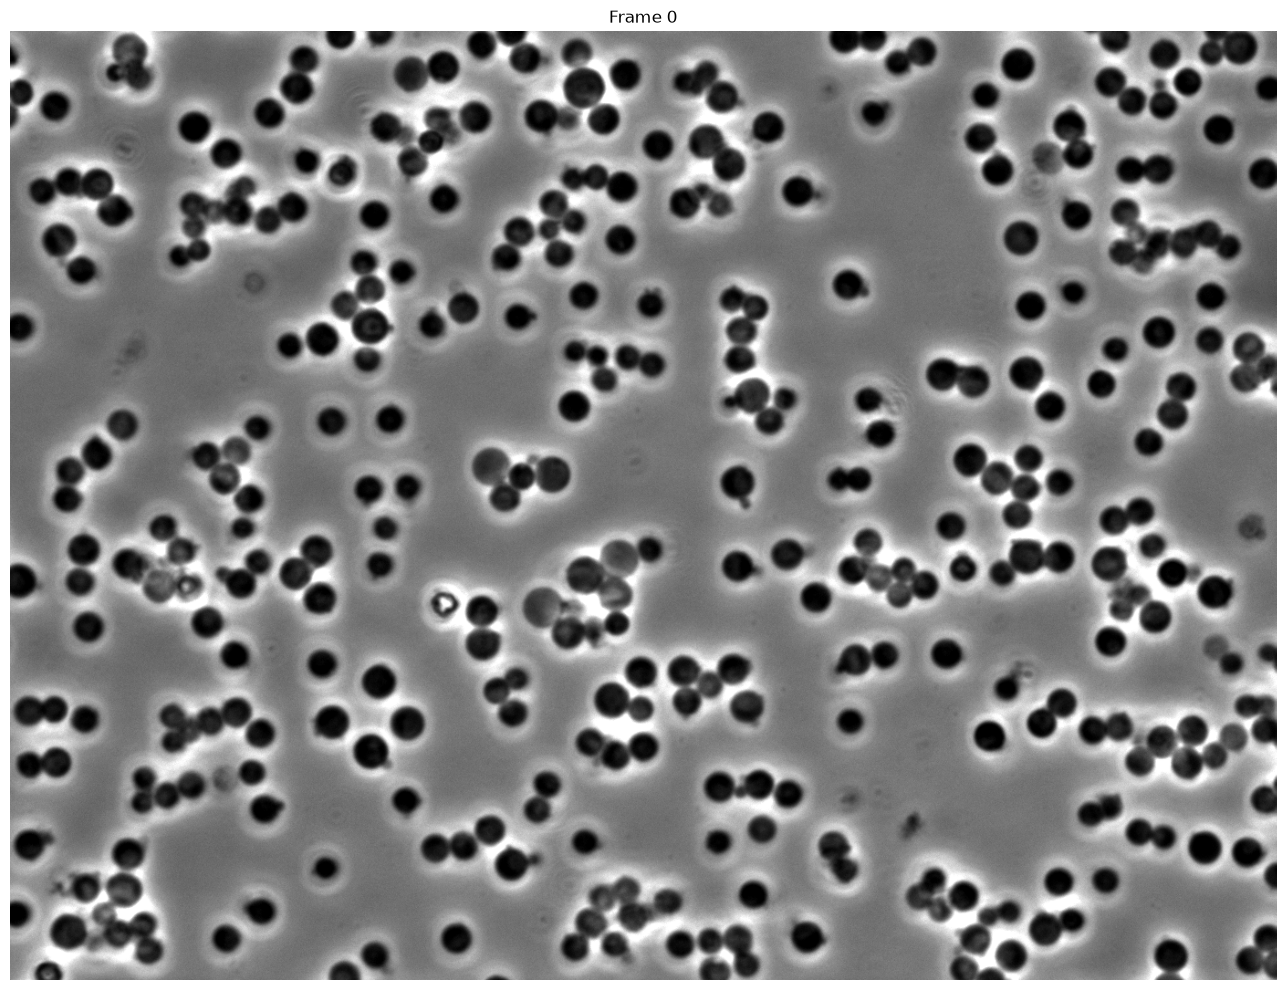

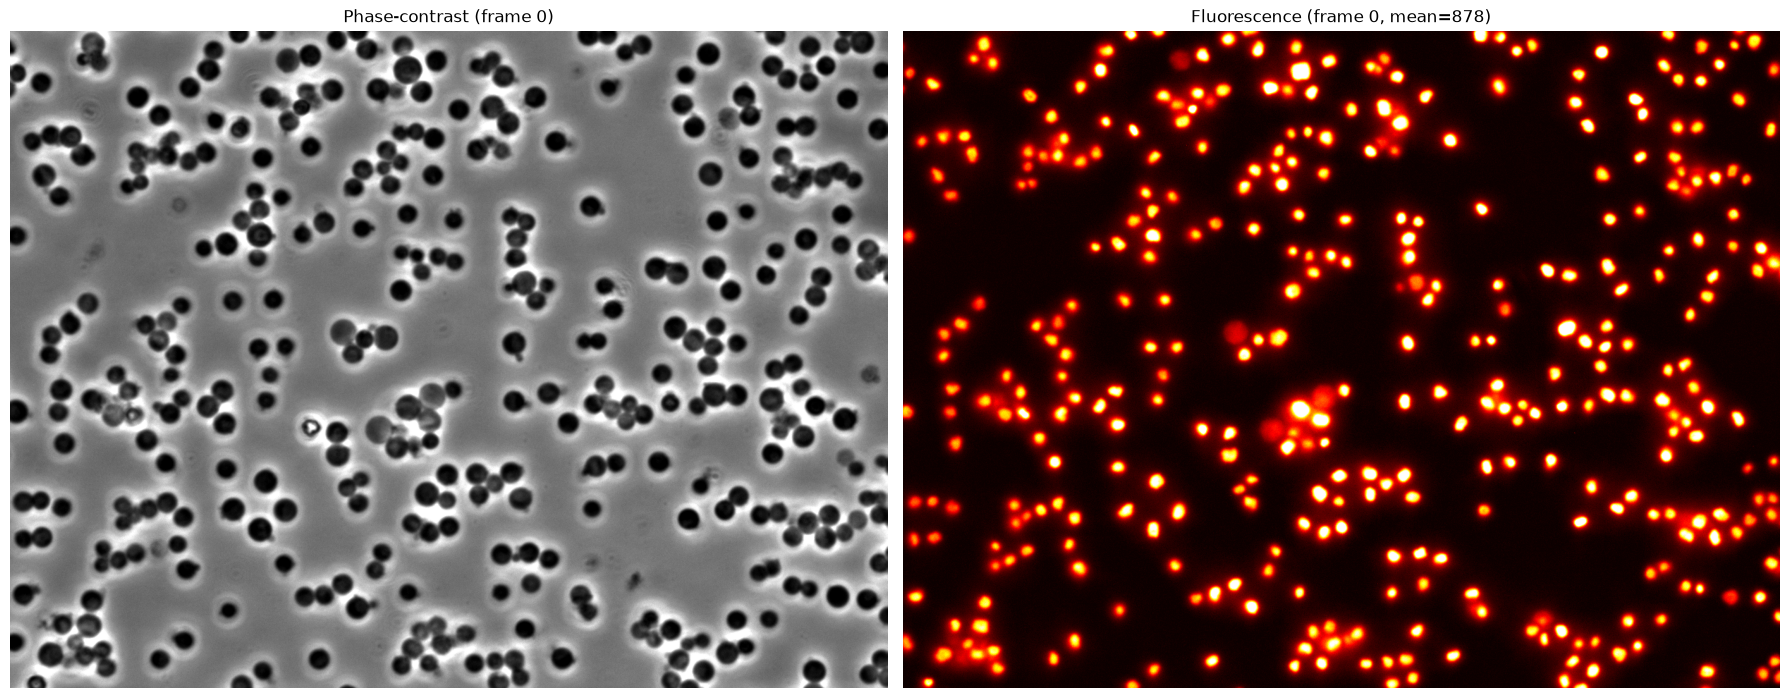

In [3]:
phase_stack, fluor_stack = load_experiment(STACK_PATH, FLUOR_PATH)
plot_frame_preview(phase_stack)
plot_channels_preview(phase_stack, fluor_stack)

## 2. Cellpose detection (phase channel)

  Frame  0: 293 cells
  Frame  1: 291 cells
  Frame  2: 300 cells
  Frame  3: 290 cells
  Frame  4: 307 cells
  Frame  5: 306 cells
  Frame  6: 300 cells
  Frame  7: 307 cells
  Frame  8: 300 cells
  Frame  9: 293 cells
  Frame 10: 276 cells
  Frame 11: 248 cells
  Frame 12: 230 cells
  Frame 13: 205 cells
  Frame 14: 178 cells
  Frame 15: 150 cells
  Frame 16: 119 cells
  Frame 17: 108 cells
  Frame 18: 93 cells
  Frame 19: 80 cells
  Frame 20: 51 cells
  Frame 21: 33 cells
  Frame 22: 29 cells
  Frame 23: 26 cells
  Frame 24: 27 cells
  Frame 25: 21 cells
  Frame 26: 11 cells
  Frame 27: 19 cells
  Frame 28: 21 cells
  Frame 29: 23 cells


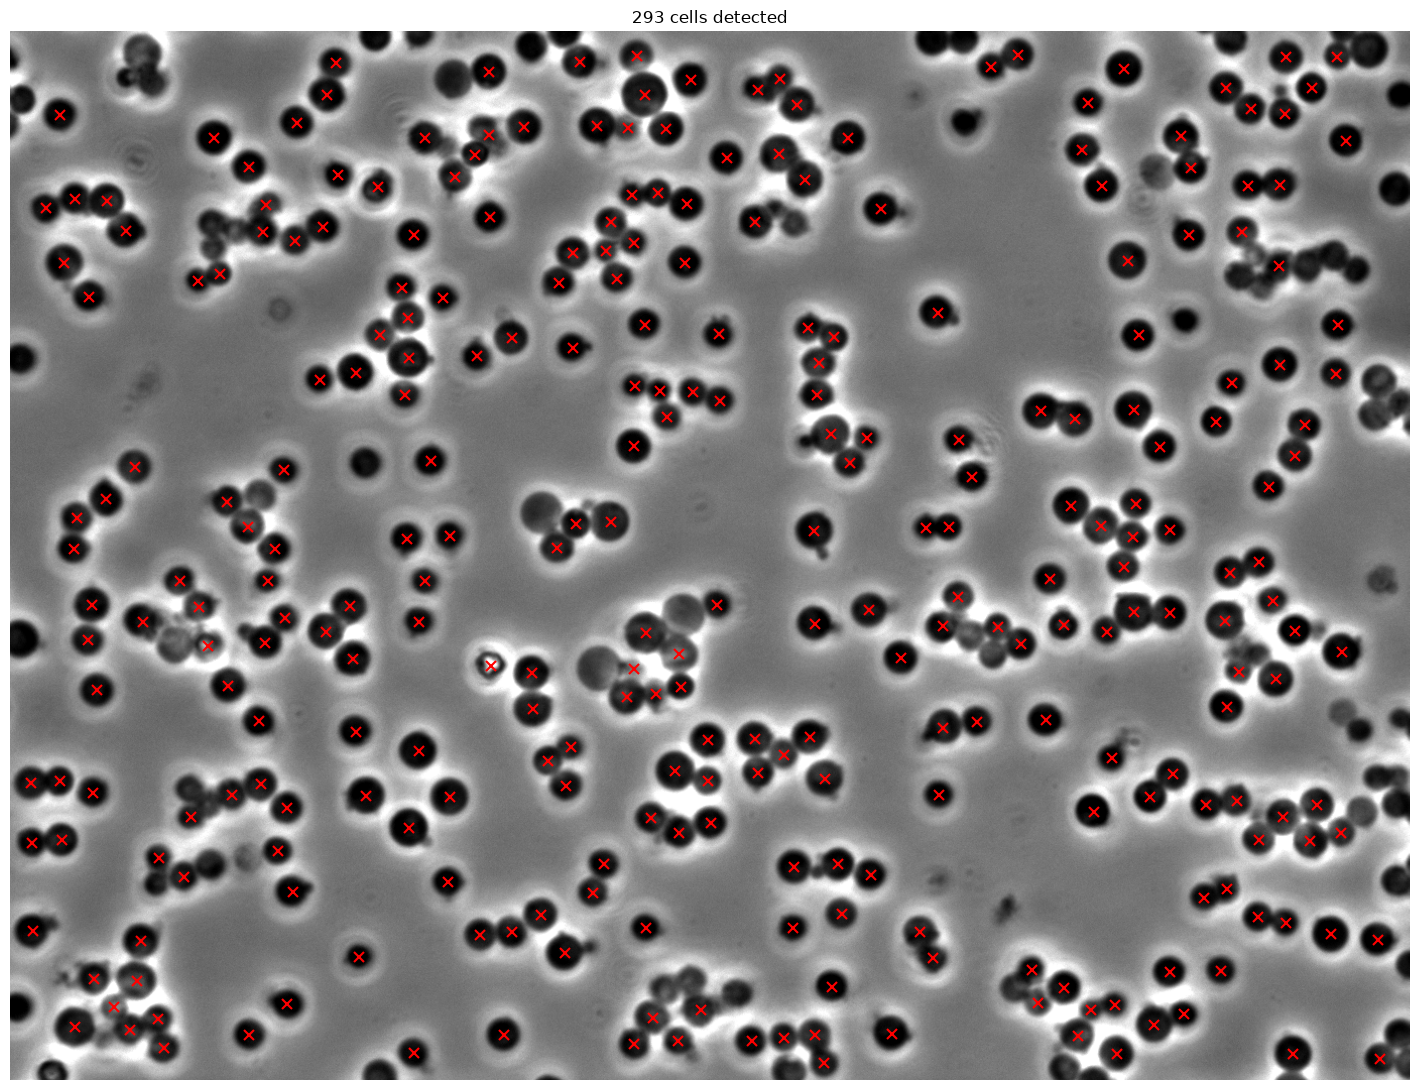

In [4]:
centroids_all, label_stack = detect_cells_stack(
    phase_stack, model_type=MODEL_TYPE, **DETECT_PARAMS,
)
plot_detections(phase_stack[0], centroids_all[0])

## 3. Frame gating

In [5]:
detections, bad_frames, diagnostics = run_frame_gating(
    label_stack, z_threshold=GATING_Z_THRESHOLD, results_dir=EXTRACTION_DIR,
)
plot_frame_gating(diagnostics, bad_frames)

Frame gating: no anomalous frames detected
No frames dropped — all frames passed quality gating.


## 4. Tracking + merging + minimum lifetime

In [6]:
tracked, track_stats, merge_log = run_tracking(
    detections,
    search_range=SEARCH_RANGE, memory=MEMORY,
    merge_max_distance=MERGE_MAX_DISTANCE, merge_max_gap=MERGE_MAX_GAP,
)
tracked, track_stats = filter_short_tracks(
    tracked, track_stats, min_detections=MIN_TRACK_DETECTIONS,
)

Frame 29: 23 trajectories present.
Unique tracks (before merging): 345
Track merging: 345 → 332 tracks (13 merges, 13 fragments absorbed)
Unique tracks (after merging): 332
Cells that disappeared before last frame: 309

Merge log (13 merges):


,absorbed_track,into_track,distance,gap_frames,end_frame,start_frame
0,342,123,0.9,5,24,29
1,338,20,1.3,5,19,24
2,340,10,1.6,7,20,27
3,343,215,2.1,6,23,29
4,320,291,2.3,5,0,5
5,326,204,2.4,7,1,8
6,325,295,4.5,7,1,8
7,335,274,5.0,8,9,17
8,334,263,7.2,6,11,17
9,329,50,9.1,5,7,12


Removed 16 tracks with <4 detections (16 were classified as disappeared)
Remaining: 316 tracks, 293 disappeared


## 5. Nucleus detection (fluor channel)

In [7]:
nucleus_label_stack = detect_nuclei_stack(
    fluor_stack, diameter=NUCLEUS_DIAMETER, min_area=NUCLEUS_MIN_AREA,
    gpu=DETECT_PARAMS.get("gpu", False),
)

  Frame  0: 362 nuclei
  Frame  1: 356 nuclei
  Frame  2: 347 nuclei
  Frame  3: 355 nuclei
  Frame  4: 350 nuclei
  Frame  5: 345 nuclei
  Frame  6: 352 nuclei
  Frame  7: 343 nuclei
  Frame  8: 339 nuclei
  Frame  9: 326 nuclei
  Frame 10: 310 nuclei
  Frame 11: 274 nuclei
  Frame 12: 279 nuclei
  Frame 13: 240 nuclei
  Frame 14: 210 nuclei
  Frame 15: 182 nuclei
  Frame 16: 148 nuclei
  Frame 17: 120 nuclei
  Frame 18: 130 nuclei
  Frame 19: 108 nuclei
  Frame 20: 84 nuclei
  Frame 21: 65 nuclei
  Frame 22: 64 nuclei
  Frame 23: 57 nuclei
  Frame 24: 51 nuclei
  Frame 25: 50 nuclei
  Frame 26: 49 nuclei
  Frame 27: 50 nuclei
  Frame 28: 50 nuclei
  Frame 29: 50 nuclei


## 6. Persist extraction bundle

In [8]:
# Persist the extraction bundle.
# `finalize_extraction_run` builds the provenance dict, derives
# dropped_frames from `diagnostics`, and writes all 8 artifacts under
# EXTRACTION_DIR. The `params` dict is built from the canonical
# EXTRACTION_PARAM_NAMES list so adding a new param means one edit in
# src/cell_analysis/io.py — the notebook doesn't need updating here.
params = {k: globals()[k] for k in EXTRACTION_PARAM_NAMES}

provenance = finalize_extraction_run(
    EXTRACTION_DIR,
    label_stack=label_stack,
    nucleus_label_stack=nucleus_label_stack,
    tracked=tracked, track_stats=track_stats,
    diagnostics=diagnostics, merge_log=merge_log,
    params=params,
    stack_path=STACK_PATH, fluor_path=FLUOR_PATH,
    repo_root=Path("..").resolve(),
)
print(f"Wrote extraction bundle to {EXTRACTION_DIR}")

Wrote extraction bundle to ..\results\protein_synthesis_arrested_1\extraction
